In [1]:
# If you do not use colab. You should install these packages.
# !pip install numpy
# !pip install pandas
# !pip install matplotlib
# !pip install scikit-learn
# !pip install graphviz

In [2]:
%matplotlib inline
%reload_ext autoreload
%autoreload 2

In [3]:
from model.metrics import MSE
from model.gradients import MSE_grad
from model.utils import *
import matplotlib.pyplot as plt
seed=42
np.random.seed(seed)

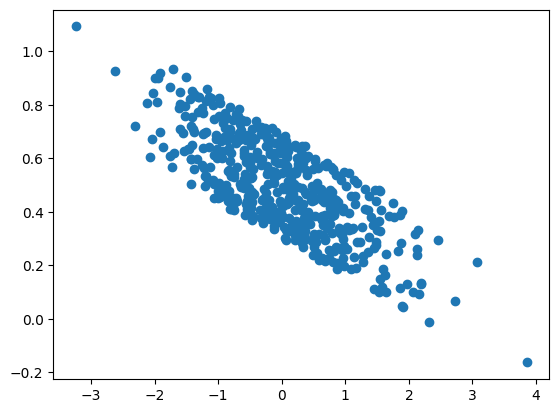

In [4]:
# Sample Code for generating datasets
seed=42
np.random.seed(seed)
size = 500
dim = 1
noise_bound = 0.2
X,y,W = generate_linear_dataset(size,dim,noise_bound=noise_bound,is_reg=True)
plt.scatter(X[:,1],y)

In [5]:
loaded_data = np.load(f'data/linear_data_A.npz')

X = loaded_data['X_data']
y = loaded_data['y_data']
W = loaded_data['W_data']
print(f"X size : {X.shape}, y size : {y.shape}")
size = X.shape[0]
dim = X.shape[1]-1

X size : (1600, 2), y size : (1600,)


20. Training loss: 0.24936302539177838, Val loss:0.23779367775290092
40. Training loss: 0.1231174555190794, Val loss:0.11681806641746473
60. Training loss: 0.06443422445965456, Val loss:0.06072159682449448
80. Training loss: 0.0371499348879804, Val loss:0.03474088572672314
100. Training loss: 0.024461533163063466, Val loss:0.022730598385935274
120. Training loss: 0.01855963209586906, Val loss:0.01719436666565952
140. Training loss: 0.015813869547551603, Val loss:0.014653424498595542
160. Training loss: 0.014536208666719716, Val loss:0.013494844785490758
180. Training loss: 0.013941580450135275, Val loss:0.01297184400194281
200. Training loss: 0.013664791563666536, Val loss:0.012739408114859366


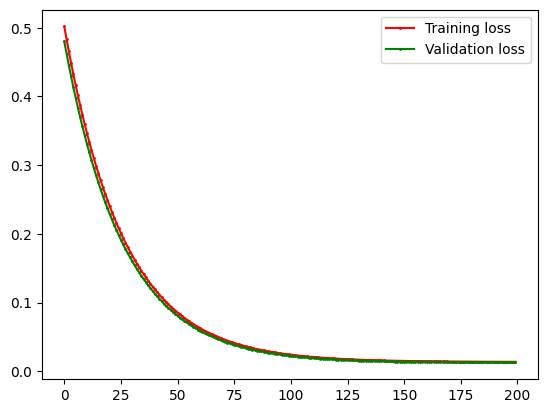

In [8]:

from model.linear_model import LinearModel
seed=42
np.random.seed(seed)
loss_fn = MSE
grad_fn = MSE_grad
X_train,y_train,X_val,y_val = get_train_val(X,y)
model = LinearModel(dim,True,loss_fn,grad_fn)
model.fit(X_train,y_train,lr=0.01,n_iteration =200,val_ratio=0.2)

MSE on valid set: 
0.013270562469488462


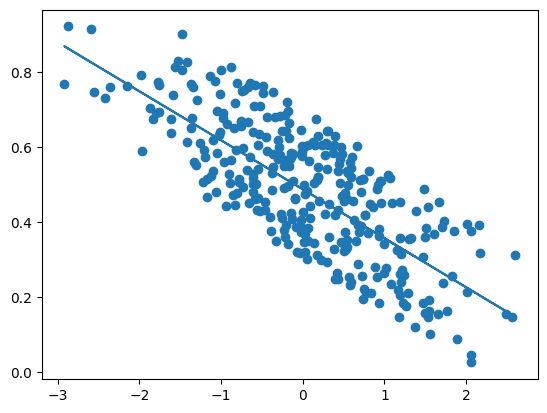

In [9]:
y_val_pred = model.predict(X_val)
print('MSE on valid set: ')
print(MSE(y_val,y_val_pred))
plt.scatter(X_val[:,1],y_val)
plt.plot(X_val[:,1],y_val_pred)
plt.show()